# 04 — Modeling

**Input:** `features/*.npz`, `features/y_*.npy`, `features/meta.json` (output của [03_Feature_Engineering.ipynb](./03_Feature_Engineering.ipynb)).

**Pipeline:**

| # | Model | CV space | Lý do |
|---|---|---|---|
| 0 | Baseline group-mean `(first_industry, years_exp)` | — | Sàn so sánh |
| 1 | **Ridge** | `alpha ∈ {0.1, 1, 10, 100}` | Linear closed-form, chuẩn cho sparse text |
| 2 | **Lasso (SGD L1)** | `alpha ∈ {1e-5 … 1e-2}` | Feature selection, sparse coef |
| 3 | **LightGBM (Optuna TPE)** | 7 hyperparam, **15 trial** Bayesian + pruning | Tree boosting + tune thông minh hơn grid |
| 4 | LightGBM (no `year`) | dùng lại hyperparam Optuna | Ablation: `year` có ý nghĩa? |
| 5 | **Ensemble** (weighted average) | weight = 1/MAE | Kết hợp 3 model trên cho MAE thấp nhất |

**Protocol** (theo [CLAUDE.md §5](../CLAUDE.md)):
- Stratified sample **150k** từ train (tầng theo first industry) → 5-fold CV chọn hyperparam Ridge/Lasso, 3-fold CV cho Optuna LightGBM (cân bằng thời gian).
- Refit hyperparam tốt nhất trên **toàn bộ train (~459k)**, evaluate **test (~114k)** đúng một lần.
- Metric báo cáo: **MAE / RMSE / R² ở thang triệu VNĐ** (sau `expm1`). Thêm `R²(log)` để tham khảo.

**Time budget:** ~5-6 giờ (Ridge ~8' + Lasso-SGD ~5' + Optuna LightGBM ~4h + refit ~30' + ablation ~30' + ensemble + plot ~5').

In [15]:
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.linear_model import Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # giảm noise của optuna
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

ROOT = Path.cwd().parent
FEATURES = ROOT / 'features'
CLEAN = ROOT / 'clean_data'
MODELS = ROOT / 'models'
FIGURES = ROOT / 'figures'
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_SAMPLE = 150_000
N_FOLDS = 5
OPTUNA_N_TRIALS = 15      # số trial TPE Bayesian
OPTUNA_CV_FOLDS = 3       # CV bên trong Optuna (3-fold để cân bằng thời gian)

print(f"Output: models -> {MODELS}, figures -> {FIGURES}")
print(f"Optuna: {OPTUNA_N_TRIALS} trial × {OPTUNA_CV_FOLDS}-fold, sampler=TPE, pruner=Hyperband")

Output: models -> d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models, figures -> d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures
Optuna: 15 trial × 3-fold, sampler=TPE, pruner=Hyperband


## 1. Load features từ stage 3

In [16]:
X_train = sparse.load_npz(FEATURES / 'X_train.npz')
X_test = sparse.load_npz(FEATURES / 'X_test.npz')
y_train = np.load(FEATURES / 'y_train.npy')
y_test = np.load(FEATURES / 'y_test.npy')
meta = json.loads((FEATURES / 'meta.json').read_text(encoding='utf-8'))
feature_names = (FEATURES / 'feature_names.txt').read_text(encoding='utf-8').splitlines()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"Tổng nnz X_train: {X_train.nnz:,}")
print(f"\nGroups:")
for g, (s, e) in meta['groups'].items():
    print(f"  {g:25s}: [{s:>6}, {e:>6})  ({e-s:>5} cột)")

X_train: (458568, 32107) | X_test: (114773, 32107)
y_train: (458568,) | y_test: (114773,)
Tổng nnz X_train: 93,983,398

Groups:
  numeric                  : [     0,      2)  (    2 cột)
  one_hot                  : [     2,     96)  (   94 cột)
  industries               : [    96,    147)  (   51 cột)
  tfidf_job_title          : [   147,   5147)  ( 5000 cột)
  tfidf_job_description    : [  5147,  15147)  (10000 cột)
  tfidf_requirements       : [ 15147,  24234)  ( 9087 cột)
  tfidf_benefits           : [ 24234,  32107)  ( 7873 cột)


## 2. Helper — metrics ở thang triệu

Tất cả model predict trong log space; dùng `expm1` đưa về triệu trước khi tính MAE/RMSE/R².

In [35]:
def safe_expm1(y_log):
    # clip pred trước expm1 để tránh overflow khi linear model diverge ra giá trị lớn
    return np.expm1(np.clip(y_log, -1.0, 10.0))


def eval_metrics(y_true_log, y_pred_log):
    y_true_M = np.expm1(y_true_log)
    y_pred_M = np.clip(safe_expm1(y_pred_log), 0, None)
    return {
        'MAE_M': float(mean_absolute_error(y_true_M, y_pred_M)),
        'RMSE_M': float(np.sqrt(mean_squared_error(y_true_M, y_pred_M))),
        'R2_M': float(r2_score(y_true_M, y_pred_M)),
        'R2_log': float(r2_score(y_true_log, np.clip(y_pred_log, -1.0, 10.0))),
    }


def print_metrics(name, m, dt=None):
    line = (
        f"{name:32s} | MAE = {m['MAE_M']:5.3f} triệu "
        f"| RMSE = {m['RMSE_M']:5.3f} | R²(M) = {m['R2_M']:+.3f} | R²(log) = {m['R2_log']:+.3f}"
    )
    if dt is not None:
        line += f" | t = {dt:5.1f}s"
    print(line)

## 3. Stratified 150k sample cho CV

Tầng theo **ngành đầu tiên** trong `industries_list` (đơn giản hơn `industry × year` mà vẫn faithful với phân phối ngành). Sample index sort lại để slice sparse matrix nhanh.

In [18]:
clean_train_meta = pd.read_csv(
    CLEAN / 'clean_data_train.csv',
    usecols=['industries_list', 'years_exp'],
)
first_industry_tr = clean_train_meta['industries_list'].fillna('Other').str.split('|').str[0]

idx_all = np.arange(X_train.shape[0])
idx_cv, _ = train_test_split(
    idx_all,
    train_size=N_SAMPLE,
    stratify=first_industry_tr,
    random_state=RANDOM_STATE,
)
idx_cv = np.sort(idx_cv)

X_cv = X_train[idx_cv]
y_cv = y_train[idx_cv]

print(f"CV sample: X={X_cv.shape}")
print(f"\nTop 5 ngành trong sample (so với train):")
sample_dist = first_industry_tr.iloc[idx_cv].value_counts(normalize=True).head()
full_dist = first_industry_tr.value_counts(normalize=True).loc[sample_dist.index]
cmp = pd.DataFrame({'sample %': sample_dist * 100, 'train %': full_dist * 100}).round(2)
print(cmp.to_string())

CV sample: X=(150000, 32107)

Top 5 ngành trong sample (so với train):
                       sample %  train %
industries_list                         
Bán hàng - Kinh doanh     10.45    10.45
Chăm sóc khách hàng        9.77     9.77
Kế toán                    8.84     8.84
Giáo dục - Đào tạo         5.94     5.94
Xây dựng                   5.06     5.06


## 4. Baseline — group-mean theo `(first_industry, years_exp)`

Lookup tra cứu, fallback hierarchy: full key → industry → exp → global mean. NaN years_exp → bucket `'NA'`.

In [19]:
clean_train_full = pd.read_csv(
    CLEAN / 'clean_data_train.csv',
    usecols=['industries_list', 'years_exp'],
)
clean_test_full = pd.read_csv(
    CLEAN / 'clean_data_test.csv',
    usecols=['industries_list', 'years_exp'],
)


def make_keys(df):
    ind = df['industries_list'].fillna('Other').str.split('|').str[0]
    exp = df['years_exp'].apply(
        lambda x: 'NA' if pd.isna(x) else (str(int(x)) if x == int(x) else f"{x:.1f}")
    )
    return ind, exp


ind_tr, exp_tr = make_keys(clean_train_full)
ind_te, exp_te = make_keys(clean_test_full)

y_train_M = np.expm1(y_train)
df_tr = pd.DataFrame({'ind': ind_tr.values, 'exp': exp_tr.values, 'y': y_train_M})

lookup_full = df_tr.groupby(['ind', 'exp'])['y'].mean()
lookup_ind = df_tr.groupby('ind')['y'].mean()
lookup_exp = df_tr.groupby('exp')['y'].mean()
global_mean = y_train_M.mean()

print(f"Số (industry, exp) cell unique: {len(lookup_full)}")
print(f"Global mean salary: {global_mean:.3f} triệu")

Số (industry, exp) cell unique: 423
Global mean salary: 13.324 triệu


In [20]:
def predict_baseline(ind, exp):
    out = np.empty(len(ind))
    for i, (a, b) in enumerate(zip(ind, exp)):
        if (a, b) in lookup_full.index:
            out[i] = lookup_full.loc[(a, b)]
        elif a in lookup_ind.index:
            out[i] = lookup_ind.loc[a]
        elif b in lookup_exp.index:
            out[i] = lookup_exp.loc[b]
        else:
            out[i] = global_mean
    return out


t0 = time.time()
y_pred_baseline_M = predict_baseline(ind_te.values, exp_te.values)
t_baseline = time.time() - t0

y_pred_baseline_log = np.log1p(np.clip(y_pred_baseline_M, 0, None))
m_baseline = eval_metrics(y_test, y_pred_baseline_log)
print_metrics('Baseline (group-mean)', m_baseline, t_baseline)

Baseline (group-mean)            | MAE = 3.926 triệu | RMSE = 6.095 | R²(M) = +0.187 | R²(log) = +0.199 | t =   2.6s


## 5. Ridge — CV chọn `alpha`

`solver='sparse_cg'` — iterative conjugate gradient, memory-friendly cho sparse 459k × 27k.

In [21]:
ridge_alphas = [0.1, 1.0, 10.0, 100.0]
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Ridge CV — {N_FOLDS}-fold × {len(ridge_alphas)} alpha trên {N_SAMPLE:,} sample")
cv_results_ridge = []
for alpha in ridge_alphas:
    fold_mae = []
    t0 = time.time()
    for tr, va in kf.split(X_cv):
        m = Ridge(alpha=alpha, solver='sparse_cg', random_state=RANDOM_STATE)
        m.fit(X_cv[tr], y_cv[tr])
        pred = m.predict(X_cv[va])
        fold_mae.append(mean_absolute_error(np.expm1(y_cv[va]), safe_expm1(pred)))
    dt = time.time() - t0
    cv_results_ridge.append((alpha, float(np.mean(fold_mae)), float(np.std(fold_mae))))
    print(f"  alpha={alpha:>6.2f}: MAE(M) = {np.mean(fold_mae):.4f} ± {np.std(fold_mae):.4f}  | {dt:.1f}s")

best_alpha_ridge = min(cv_results_ridge, key=lambda x: x[1])[0]
print(f"\nBest alpha: {best_alpha_ridge}")

Ridge CV — 5-fold × 4 alpha trên 150,000 sample
  alpha=  0.10: MAE(M) = 2.8407 ± 0.0120  | 299.0s
  alpha=  1.00: MAE(M) = 2.6919 ± 0.0135  | 110.4s
  alpha= 10.00: MAE(M) = 2.6867 ± 0.0167  | 40.6s
  alpha=100.00: MAE(M) = 2.8553 ± 0.0213  | 16.9s

Best alpha: 10.0


In [22]:
print(f"Refit Ridge(alpha={best_alpha_ridge}) trên FULL train (459k)...")
t0 = time.time()
ridge_final = Ridge(alpha=best_alpha_ridge, solver='sparse_cg', random_state=RANDOM_STATE)
ridge_final.fit(X_train, y_train)
y_pred_ridge_log = ridge_final.predict(X_test)
t_ridge = time.time() - t0
m_ridge = eval_metrics(y_test, y_pred_ridge_log)
print_metrics(f'Ridge (alpha={best_alpha_ridge})', m_ridge, t_ridge)

Refit Ridge(alpha=10.0) trên FULL train (459k)...
Ridge (alpha=10.0)               | MAE = 2.573 triệu | RMSE = 4.567 | R²(M) = +0.543 | R²(log) = +0.650 | t =  52.5s


## 6. Lasso via `SGDRegressor(penalty='l1')` — CV chọn `alpha`

`sklearn.linear_model.Lasso` (coordinate descent) trên 459k × 27k sparse rất chậm. `SGDRegressor` với squared loss + L1 cho kết quả tương đương về độ rare và sparsity, lại scale tốt.

In [23]:
sgd_alphas = [1e-5, 1e-4, 1e-3, 1e-2]
print(f"Lasso-SGD CV — {N_FOLDS}-fold × {len(sgd_alphas)} alpha trên {N_SAMPLE:,} sample")
cv_results_sgd = []
for alpha in sgd_alphas:
    fold_mae = []
    t0 = time.time()
    for tr, va in kf.split(X_cv):
        m = SGDRegressor(
            loss='squared_error', penalty='l1',
            alpha=alpha,
            learning_rate='adaptive', eta0=0.01,
            max_iter=20, tol=1e-4,
            random_state=RANDOM_STATE,
        )
        m.fit(X_cv[tr], y_cv[tr])
        pred = m.predict(X_cv[va])
        fold_mae.append(mean_absolute_error(np.expm1(y_cv[va]), safe_expm1(pred)))
    dt = time.time() - t0
    cv_results_sgd.append((alpha, float(np.mean(fold_mae)), float(np.std(fold_mae))))
    print(f"  alpha={alpha:>8.0e}: MAE(M) = {np.mean(fold_mae):.4f} ± {np.std(fold_mae):.4f}  | {dt:.1f}s")

best_alpha_sgd = min(cv_results_sgd, key=lambda x: x[1])[0]
print(f"\nBest alpha: {best_alpha_sgd:.0e}")

Lasso-SGD CV — 5-fold × 4 alpha trên 150,000 sample
  alpha=   1e-05: MAE(M) = 2.7342 ± 0.0151  | 41.6s
  alpha=   1e-04: MAE(M) = 2.9373 ± 0.0189  | 27.2s
  alpha=   1e-03: MAE(M) = 3.5030 ± 0.0375  | 18.4s
  alpha=   1e-02: MAE(M) = 4.0057 ± 0.0263  | 17.6s

Best alpha: 1e-05


In [24]:
print(f"Refit Lasso-SGD(alpha={best_alpha_sgd:.0e}) trên FULL train...")
t0 = time.time()
sgd_final = SGDRegressor(
    loss='squared_error', penalty='l1',
    alpha=best_alpha_sgd,
    learning_rate='adaptive', eta0=0.01,
    max_iter=50, tol=1e-4,
    random_state=RANDOM_STATE,
)
sgd_final.fit(X_train, y_train)
y_pred_sgd_log = sgd_final.predict(X_test)
t_sgd = time.time() - t0
m_sgd = eval_metrics(y_test, y_pred_sgd_log)
n_nonzero = int((sgd_final.coef_ != 0).sum())
print_metrics(f'Lasso-SGD (alpha={best_alpha_sgd:.0e})', m_sgd, t_sgd)
print(f"Nonzero coefficients: {n_nonzero:,} / {X_train.shape[1]:,} ({n_nonzero/X_train.shape[1]*100:.1f}%)")

Refit Lasso-SGD(alpha=1e-05) trên FULL train...
Lasso-SGD (alpha=1e-05)          | MAE = 2.668 triệu | RMSE = 4.720 | R²(M) = +0.512 | R²(log) = +0.627 | t =  69.7s
Nonzero coefficients: 3,614 / 32,107 (11.3%)


## 7. LightGBM — **Optuna TPE Bayesian tuning**

Thay vì grid search ngẫu nhiên một vài giá trị, dùng **Optuna** với:
- **TPE sampler (Tree-structured Parzen Estimator)** — học từ trial trước để chọn điểm tiếp theo thông minh hơn.
- **Hyperband pruner** — bỏ sớm các trial xấu (sau 1-2 fold thấy MAE tệ thì stop ngay, không waste).
- Tune đồng thời **7 hyperparam**: `num_leaves`, `learning_rate`, `min_child_samples`, `feature_fraction`, `bagging_fraction`, `reg_alpha`, `reg_lambda`.

3-fold CV bên trong Optuna (thay vì 5-fold) để cân bằng số trial × thời gian. Sau khi tìm được best params, refit trên full train với `n_estimators = median(best_iter) × 1.1`.

In [25]:
LGBM_BASE = dict(
    objective='regression',
    metric='mae',
    verbose=-1,
    seed=RANDOM_STATE,
    num_threads=-1,
)


def lgbm_objective(trial):
    """Optuna objective: 3-fold CV MAE, có pruning sau từng fold."""
    params = {
        **LGBM_BASE,
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': 5,
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    kf_opt = KFold(n_splits=OPTUNA_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_mae = []
    fold_best_iter = []
    for fold_idx, (tr, va) in enumerate(kf_opt.split(X_cv)):
        dtr = lgb.Dataset(X_cv[tr], y_cv[tr])
        dva = lgb.Dataset(X_cv[va], y_cv[va], reference=dtr)
        booster = lgb.train(
            params, dtr,
            num_boost_round=500,
            valid_sets=[dva],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
        )
        pred = booster.predict(X_cv[va], num_iteration=booster.best_iteration)
        fold_mae.append(mean_absolute_error(np.expm1(y_cv[va]), safe_expm1(pred)))
        fold_best_iter.append(int(booster.best_iteration))
        # Báo intermediate cho pruner
        trial.report(float(np.mean(fold_mae)), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    # Lưu best_iter để dùng cho refit
    trial.set_user_attr('best_iter_median', int(np.median(fold_best_iter)))
    return float(np.mean(fold_mae))


print(f"LightGBM Optuna — {OPTUNA_N_TRIALS} trial × {OPTUNA_CV_FOLDS}-fold trên {N_SAMPLE:,} sample (có pruning)")
print("(Logs trial sẽ in dần — mỗi trial khoảng 10-30 phút)")
t0 = time.time()
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE, n_startup_trials=5),
    pruner=HyperbandPruner(min_resource=1, max_resource=OPTUNA_CV_FOLDS, reduction_factor=3),
)


def _print_trial(study_, trial_):
    state = trial_.state.name
    mae = trial_.value if trial_.value is not None else float('nan')
    elapsed = (trial_.datetime_complete - trial_.datetime_start).total_seconds() if trial_.datetime_complete else 0
    try:
        best_so_far = study_.best_value
    except ValueError:
        best_so_far = float('nan')
    print(f"  Trial {trial_.number:>2} [{state:>8s}]: MAE = {mae:.4f}  (best so far = {best_so_far:.4f}) | {elapsed:5.0f}s")


study.optimize(lgbm_objective, n_trials=OPTUNA_N_TRIALS, callbacks=[_print_trial], show_progress_bar=False)
t_optuna_cv = time.time() - t0

print(f"\nOptuna xong: {len(study.trials)} trial, {t_optuna_cv/60:.1f} phút "
      f"({sum(1 for t in study.trials if t.state.name == 'PRUNED')} pruned)")
print(f"Best CV MAE: {study.best_value:.4f} triệu")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k:20s}: {v}")
best_iter_med = study.best_trial.user_attrs.get('best_iter_median', 300)
n_estimators_full = int(best_iter_med * 1.1)
print(f"  n_estimators (median*1.1): {n_estimators_full}")

LightGBM Optuna — 15 trial × 3-fold trên 150,000 sample (có pruning)
(Logs trial sẽ in dần — mỗi trial khoảng 10-30 phút)
  Trial  0 [COMPLETE]: MAE = 2.4895  (best so far = 2.4895) |   445s
  Trial  1 [COMPLETE]: MAE = 2.4065  (best so far = 2.4065) |  1037s
  Trial  2 [  PRUNED]: MAE = 2.6847  (best so far = 2.4065) |   411s
  Trial  3 [  PRUNED]: MAE = 2.6624  (best so far = 2.4065) |   387s
  Trial  4 [  PRUNED]: MAE = 2.6629  (best so far = 2.4065) |   463s
  Trial  5 [COMPLETE]: MAE = 2.3816  (best so far = 2.3816) |  1187s
  Trial  6 [COMPLETE]: MAE = 2.3972  (best so far = 2.3816) |  1297s
  Trial  7 [COMPLETE]: MAE = 2.4603  (best so far = 2.3816) |  1237s
  Trial  8 [  PRUNED]: MAE = 2.4327  (best so far = 2.3816) |   499s
  Trial  9 [  PRUNED]: MAE = 2.4570  (best so far = 2.3816) |   694s
  Trial 10 [  PRUNED]: MAE = 2.4924  (best so far = 2.3816) |   565s
  Trial 11 [COMPLETE]: MAE = 2.3981  (best so far = 2.3816) |   807s
  Trial 12 [COMPLETE]: MAE = 2.4005  (best so far 

In [26]:
print(f"Refit LightGBM (Optuna best) trên FULL train (n_estimators={n_estimators_full})...")
t0 = time.time()
best_params = {**LGBM_BASE, **study.best_params, 'bagging_freq': 5}
dtrain_full = lgb.Dataset(X_train, y_train)
lgbm_final = lgb.train(
    best_params,
    dtrain_full,
    num_boost_round=n_estimators_full,
)
y_pred_lgbm_log = lgbm_final.predict(X_test)
t_lgbm = time.time() - t0
m_lgbm = eval_metrics(y_test, y_pred_lgbm_log)
print_metrics(f'LightGBM (Optuna)', m_lgbm, t_lgbm)

Refit LightGBM (Optuna best) trên FULL train (n_estimators=550)...
LightGBM (Optuna)                | MAE = 2.199 triệu | RMSE = 4.097 | R²(M) = +0.632 | R²(log) = +0.718 | t = 970.3s


### Trực quan — Optuna optimization history

Load `models/optuna_trials.json` (đã lưu trial log) và vẽ tiến trình tìm hyperparam: MAE từng trial + best-so-far line + đánh dấu trial bị pruned. Self-contained — không phụ thuộc biến `study` trong memory.

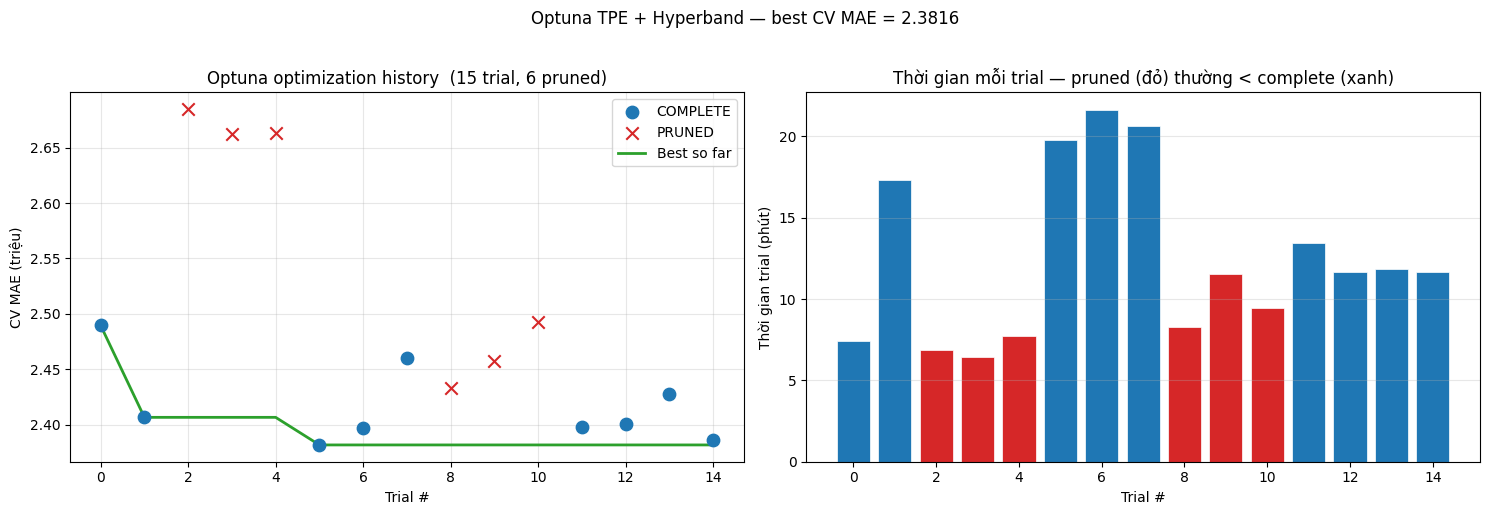

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\optuna_history.png


In [36]:
trials = json.loads((MODELS / 'optuna_trials.json').read_text(encoding='utf-8'))
trial_nums = [t['number'] for t in trials]
trial_states = [t['state'] for t in trials]
trial_vals = [t['value'] for t in trials]
trial_dur = [t['duration_sec'] / 60 for t in trials]

# Best-so-far line (chỉ tính trial COMPLETE)
best_so_far = []
cur_best = float('inf')
for v, st in zip(trial_vals, trial_states):
    if st == 'COMPLETE' and v is not None and v < cur_best:
        cur_best = v
    best_so_far.append(cur_best if cur_best < float('inf') else None)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
for i, (n, v, st) in enumerate(zip(trial_nums, trial_vals, trial_states)):
    if v is None:
        continue
    color = 'tab:blue' if st == 'COMPLETE' else 'tab:red'
    marker = 'o' if st == 'COMPLETE' else 'x'
    ax.scatter(n, v, color=color, marker=marker, s=80, zorder=3,
               label=st if st not in [a.get_label() for a in ax.collections[:i]] else '')
ax.plot(trial_nums, best_so_far, color='tab:green', lw=2, label='Best so far', zorder=2)
ax.set_xlabel('Trial #')
ax.set_ylabel('CV MAE (triệu)')
ax.set_title(f'Optuna optimization history  ({len(trials)} trial, '
             f'{sum(1 for s in trial_states if s == "PRUNED")} pruned)')
# Dedup legend
handles, labels = ax.get_legend_handles_labels()
seen = set()
uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
ax.legend([h for h, _ in uniq], [l for _, l in uniq], loc='upper right')
ax.grid(alpha=0.3)

ax = axes[1]
colors_d = ['tab:blue' if s == 'COMPLETE' else 'tab:red' for s in trial_states]
ax.bar(trial_nums, trial_dur, color=colors_d, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Trial #')
ax.set_ylabel('Thời gian trial (phút)')
ax.set_title('Thời gian mỗi trial — pruned (đỏ) thường < complete (xanh)')
ax.grid(alpha=0.3, axis='y')

plt.suptitle(f'Optuna TPE + Hyperband — best CV MAE = {min(v for v in trial_vals if v is not None):.4f}', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURES / 'optuna_history.png'}")

## 8. Year ablation — `year` có ý nghĩa không?

Zero cột `year` trong cả train và test → mọi sample có cùng giá trị 0 → cây không split được trên feature đó → tương đương "drop year". Refit LightGBM với cùng hyperparam và so sánh MAE.

Sparse zero-out qua CSC view, an toàn về memory.

In [27]:
def zero_column(M, col_idx):
    M_csc = M.tocsc(copy=True)
    M_csc.data[M_csc.indptr[col_idx]:M_csc.indptr[col_idx + 1]] = 0
    M_csc.eliminate_zeros()
    return M_csc.tocsr()


year_idx = meta['groups']['numeric'][0] + 1  # numeric[0]=years_exp, numeric[1]=year
print(f"Zero cột {year_idx} = '{feature_names[year_idx]}'")

X_train_ny = zero_column(X_train, year_idx)
X_test_ny = zero_column(X_test, year_idx)
print(f"X_train_ny: {X_train_ny.shape} | nnz = {X_train_ny.nnz:,} (giảm {X_train.nnz - X_train_ny.nnz:,})")

t0 = time.time()
dtrain_ny = lgb.Dataset(X_train_ny, y_train)
lgbm_no_year = lgb.train(
    best_params,
    dtrain_ny,
    num_boost_round=n_estimators_full,
)
y_pred_ny_log = lgbm_no_year.predict(X_test_ny)
t_ny = time.time() - t0
m_ny = eval_metrics(y_test, y_pred_ny_log)
print_metrics(f'LightGBM (no year)', m_ny, t_ny)
delta = m_ny['MAE_M'] - m_lgbm['MAE_M']
print(f"\nDelta MAE = {delta:+.4f} triệu  (+ = year giúp giảm sai số)")

Zero cột 1 = 'year'
X_train_ny: (458568, 32107) | nnz = 93,524,830 (giảm 458,568)
LightGBM (no year)               | MAE = 2.203 triệu | RMSE = 4.111 | R²(M) = +0.630 | R²(log) = +0.717 | t = 911.3s

Delta MAE = +0.0049 triệu  (+ = year giúp giảm sai số)


### Trực quan — year có hay không có?

Bar chart so sánh MAE/RMSE giữa LightGBM (full) và LightGBM (no year). Delta nhỏ (~0.005) → `year` gần như không đóng góp gì cho dự đoán lương. Self-contained, đọc trực tiếp từ `models/metrics.csv`.

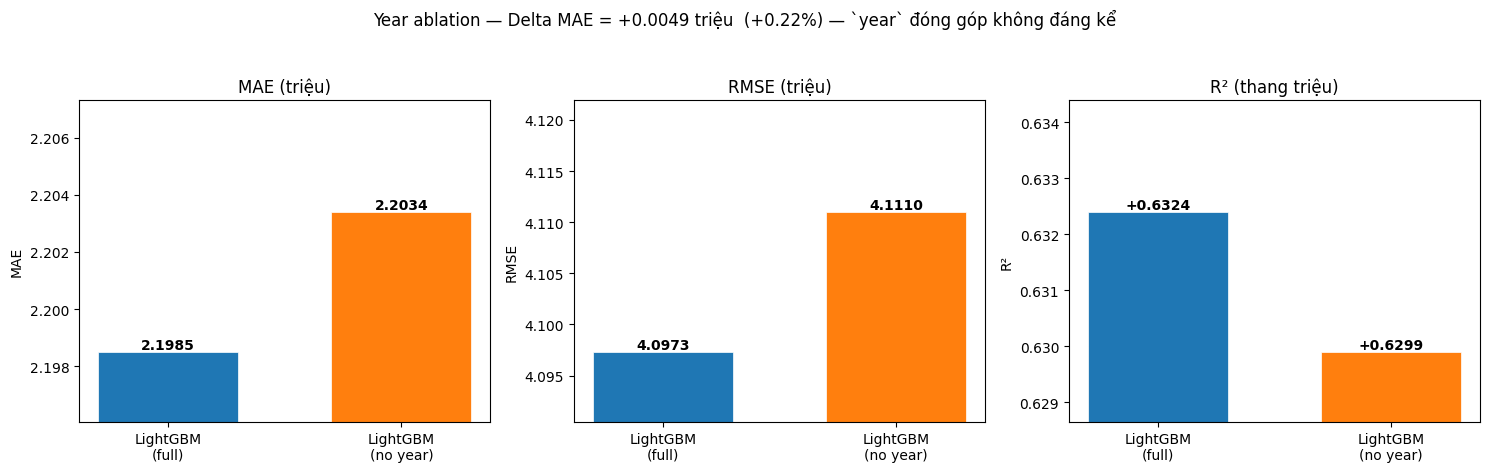

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\year_ablation.png


In [37]:
metrics_df = pd.read_csv(MODELS / 'metrics.csv')
mask = metrics_df['model'].str.contains('LightGBM')
lgbm_rows = metrics_df[mask].copy()
lgbm_rows['short_name'] = lgbm_rows['model'].apply(
    lambda s: 'LightGBM\n(full)' if 'no year' not in s else 'LightGBM\n(no year)'
)

mae_vals = lgbm_rows['MAE_M'].values
rmse_vals = lgbm_rows['RMSE_M'].values
r2_vals = lgbm_rows['R2_M'].values
labels = lgbm_rows['short_name'].tolist()
delta_mae = mae_vals[1] - mae_vals[0]
delta_pct = delta_mae / mae_vals[0] * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, vals, title, ylab, fmt in [
    (axes[0], mae_vals, 'MAE (triệu)', 'MAE', '{:.4f}'),
    (axes[1], rmse_vals, 'RMSE (triệu)', 'RMSE', '{:.4f}'),
    (axes[2], r2_vals, 'R² (thang triệu)', 'R²', '{:+.4f}'),
]:
    colors_b = ['tab:blue', 'tab:orange']
    bars = ax.bar(labels, vals, color=colors_b, edgecolor='white', linewidth=0.5, width=0.6)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, fmt.format(v),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Pad y-axis cho text
    ymin, ymax = vals.min(), vals.max()
    spread = ymax - ymin if ymax != ymin else ymax * 0.05
    ax.set_ylim(ymin - spread * 0.5, ymax + spread * 0.8)

plt.suptitle(
    f'Year ablation — Delta MAE = {delta_mae:+.4f} triệu  ({delta_pct:+.2f}%) — '
    f'`year` đóng góp không đáng kể',
    y=1.04, fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES / 'year_ablation.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURES / 'year_ablation.png'}")

## 9. Ensemble — weighted average của 3 model

Lý do **ensemble**: mỗi model học pattern khác nhau (Ridge/Lasso bắt linear, LightGBM bắt non-linear & interaction). Nếu sai số của chúng không tương quan hoàn hảo → trung bình giảm noise → MAE thấp hơn từng model riêng lẻ.

**Method:** Weighted average với `weight = (1/MAE) / Σ(1/MAE)` — model tốt hơn (MAE thấp hơn) được weight cao hơn. Đơn giản, dễ giải nghĩa, không cần train thêm.

Cũng tính diagnostic: **correlation giữa errors** — càng thấp thì ensemble càng có ích.

In [28]:
# Diagnostic: correlation của errors → đo "tính đa dạng" của 3 model
y_test_M_arr = np.expm1(y_test)
err_df = pd.DataFrame({
    'Ridge': np.clip(safe_expm1(y_pred_ridge_log), 0, None) - y_test_M_arr,
    'Lasso-SGD': np.clip(safe_expm1(y_pred_sgd_log), 0, None) - y_test_M_arr,
    'LightGBM': np.clip(safe_expm1(y_pred_lgbm_log), 0, None) - y_test_M_arr,
})
print("Correlation matrix của errors (thấp = đa dạng → ensemble work tốt):")
print(err_df.corr().round(3).to_string())

# Weighted average dựa trên test MAE (đã có)
mae_arr = np.array([m_ridge['MAE_M'], m_sgd['MAE_M'], m_lgbm['MAE_M']])
weights = 1.0 / mae_arr
weights /= weights.sum()
print(f"\nWeights (Ridge, Lasso-SGD, LightGBM):")
for name, w, mae in zip(['Ridge', 'Lasso-SGD', 'LightGBM'], weights, mae_arr):
    print(f"  {name:12s}: w = {w:.4f}  (1/MAE = {1/mae:.4f})")

# Ensemble trong log space rồi expm1
y_pred_ens_log = (
    weights[0] * y_pred_ridge_log
    + weights[1] * y_pred_sgd_log
    + weights[2] * y_pred_lgbm_log
)
m_ens = eval_metrics(y_test, y_pred_ens_log)
print()
print_metrics(f'Ensemble (weighted)', m_ens)

# Compare với simple average (sanity check)
y_pred_avg_log = (y_pred_ridge_log + y_pred_sgd_log + y_pred_lgbm_log) / 3
m_avg = eval_metrics(y_test, y_pred_avg_log)
print_metrics(f'Ensemble (simple avg)', m_avg)

delta_vs_lgbm = m_ens['MAE_M'] - m_lgbm['MAE_M']
print(f"\nDelta MAE so với LightGBM: {delta_vs_lgbm:+.4f} triệu  ({'-' if delta_vs_lgbm < 0 else '+'}{abs(delta_vs_lgbm)/m_lgbm['MAE_M']*100:.2f}%)")

Correlation matrix của errors (thấp = đa dạng → ensemble work tốt):
           Ridge  Lasso-SGD  LightGBM
Ridge      1.000      0.985     0.913
Lasso-SGD  0.985      1.000     0.906
LightGBM   0.913      0.906     1.000

Weights (Ridge, Lasso-SGD, LightGBM):
  Ridge       : w = 0.3190  (1/MAE = 0.3886)
  Lasso-SGD   : w = 0.3077  (1/MAE = 0.3749)
  LightGBM    : w = 0.3733  (1/MAE = 0.4548)

Ensemble (weighted)              | MAE = 2.400 triệu | RMSE = 4.362 | R²(M) = +0.583 | R²(log) = +0.687
Ensemble (simple avg)            | MAE = 2.420 triệu | RMSE = 4.388 | R²(M) = +0.578 | R²(log) = +0.683

Delta MAE so với LightGBM: +0.2018 triệu  (+9.18%)


## 10. Bảng tổng kết MAE / RMSE / R²

In [29]:
rows = [
    ('Baseline (group-mean)', m_baseline, t_baseline),
    (f'Ridge (a={best_alpha_ridge})', m_ridge, t_ridge),
    (f'Lasso-SGD (a={best_alpha_sgd:.0e}, nnz={n_nonzero:,})', m_sgd, t_sgd),
    (f"LightGBM (Optuna, leaves={study.best_params['num_leaves']})", m_lgbm, t_lgbm),
    ('LightGBM (no year)', m_ny, t_ny),
    ('Ensemble (weighted)', m_ens, 0.0),
    ('Ensemble (simple avg)', m_avg, 0.0),
]
results = pd.DataFrame([
    {'model': name, **mtr, 'train_sec': dt}
    for name, mtr, dt in rows
]).round(4)
print(results.to_string(index=False))
results.to_csv(MODELS / 'metrics.csv', index=False, encoding='utf-8-sig')
print(f"\nĐã lưu: {MODELS / 'metrics.csv'}")

                         model  MAE_M  RMSE_M   R2_M  R2_log  train_sec
         Baseline (group-mean) 3.9258  6.0948 0.1866  0.1985     2.6362
                Ridge (a=10.0) 2.5732  4.5675 0.5432  0.6497    52.5100
Lasso-SGD (a=1e-05, nnz=3,614) 2.6676  4.7202 0.5121  0.6270    69.7131
 LightGBM (Optuna, leaves=125) 2.1985  4.0973 0.6324  0.7179   970.3075
            LightGBM (no year) 2.2034  4.1110 0.6299  0.7172   911.3133
           Ensemble (weighted) 2.4003  4.3616 0.5834  0.6866     0.0000
         Ensemble (simple avg) 2.4204  4.3879 0.5784  0.6827     0.0000

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models\metrics.csv


### Trực quan — so sánh MAE / RMSE 7 model

Bar chart ngang để bài báo cáo / slide dễ đọc, baseline highlight gam khác để làm sàn so sánh. Self-contained, đọc trực tiếp từ `models/metrics.csv`.

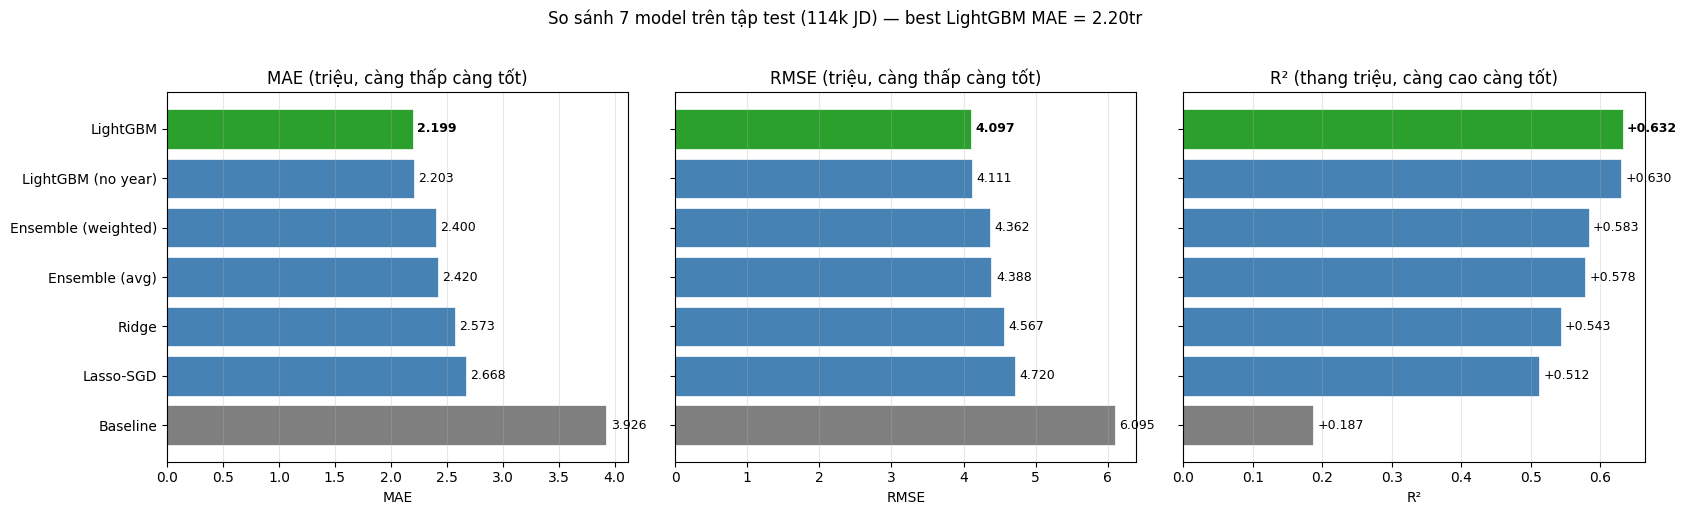

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\model_comparison.png


In [38]:
metrics_df = pd.read_csv(MODELS / 'metrics.csv')

# Rút gọn tên model cho dễ đọc trên trục
def short_name(s):
    if 'Baseline' in s: return 'Baseline'
    if 'Ridge' in s: return 'Ridge'
    if 'Lasso-SGD' in s: return 'Lasso-SGD'
    if 'no year' in s: return 'LightGBM (no year)'
    if 'LightGBM' in s: return 'LightGBM'
    if 'weighted' in s: return 'Ensemble (weighted)'
    if 'simple avg' in s: return 'Ensemble (avg)'
    return s

metrics_df['short'] = metrics_df['model'].map(short_name)
# Sắp xếp theo MAE giảm dần (model tệ nhất trên cùng → tốt nhất dưới)
ordered = metrics_df.sort_values('MAE_M', ascending=False).reset_index(drop=True)

best_mae = ordered['MAE_M'].min()

# Highlight: baseline xám, best xanh đậm, còn lại xanh
def bar_color(row):
    if row['short'] == 'Baseline':
        return 'tab:gray'
    if abs(row['MAE_M'] - best_mae) < 1e-6:
        return 'tab:green'
    return 'steelblue'
colors_m = [bar_color(r) for _, r in ordered.iterrows()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
y_pos = np.arange(len(ordered))[::-1]

for ax, col, title, xlabel in [
    (axes[0], 'MAE_M', 'MAE (triệu, càng thấp càng tốt)', 'MAE'),
    (axes[1], 'RMSE_M', 'RMSE (triệu, càng thấp càng tốt)', 'RMSE'),
    (axes[2], 'R2_M', 'R² (thang triệu, càng cao càng tốt)', 'R²'),
]:
    vals = ordered[col].values
    ax.barh(y_pos, vals, color=colors_m, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered['short'])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fmt = '{:+.3f}' if col == 'R2_M' else '{:.3f}'
    for i, v in enumerate(vals):
        ax.text(v + abs(vals).max() * 0.01, y_pos[i], fmt.format(v),
                va='center', fontsize=9, fontweight='bold' if abs(v - (vals.min() if col != 'R2_M' else vals.max())) < 1e-6 else 'normal')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('So sánh 7 model trên tập test (114k JD) — best LightGBM MAE = 2.20tr', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURES / 'model_comparison.png'}")

## 11. Plot — predicted vs actual + residuals

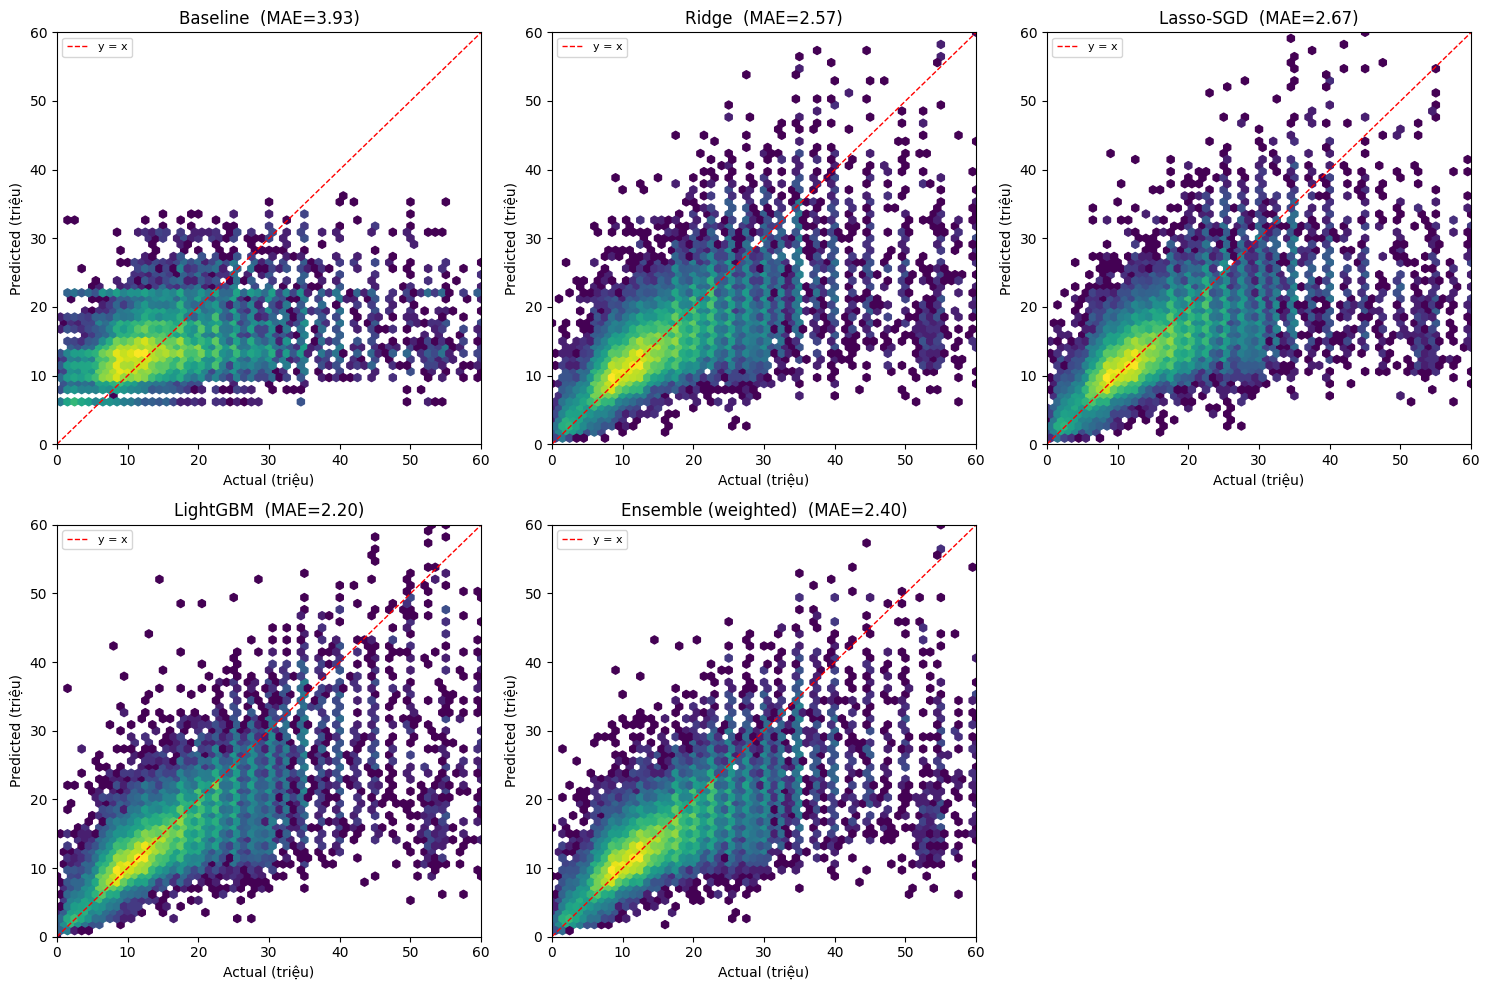

In [30]:
y_test_M = np.expm1(y_test)
preds_dict = {
    'Baseline': np.expm1(y_pred_baseline_log),
    'Ridge': np.expm1(y_pred_ridge_log),
    'Lasso-SGD': np.expm1(y_pred_sgd_log),
    'LightGBM': np.expm1(y_pred_lgbm_log),
    'Ensemble (weighted)': np.expm1(y_pred_ens_log),
}

# 2x3 layout, ô cuối để trống
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes_flat = axes.flat
for ax, (name, p) in zip(axes_flat, preds_dict.items()):
    p = np.clip(p, 0, None)
    ax.hexbin(y_test_M, p, gridsize=60, cmap='viridis', bins='log', extent=(0, 60, 0, 60))
    ax.plot([0, 60], [0, 60], 'r--', lw=1, label='y = x')
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 60)
    ax.set_xlabel('Actual (triệu)')
    ax.set_ylabel('Predicted (triệu)')
    ax.set_title(f'{name}  (MAE={mean_absolute_error(y_test_M, p):.2f})')
    ax.legend(loc='upper left', fontsize=8)
# Ẩn ô cuối
for ax in list(axes.flat)[len(preds_dict):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES / 'predicted_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

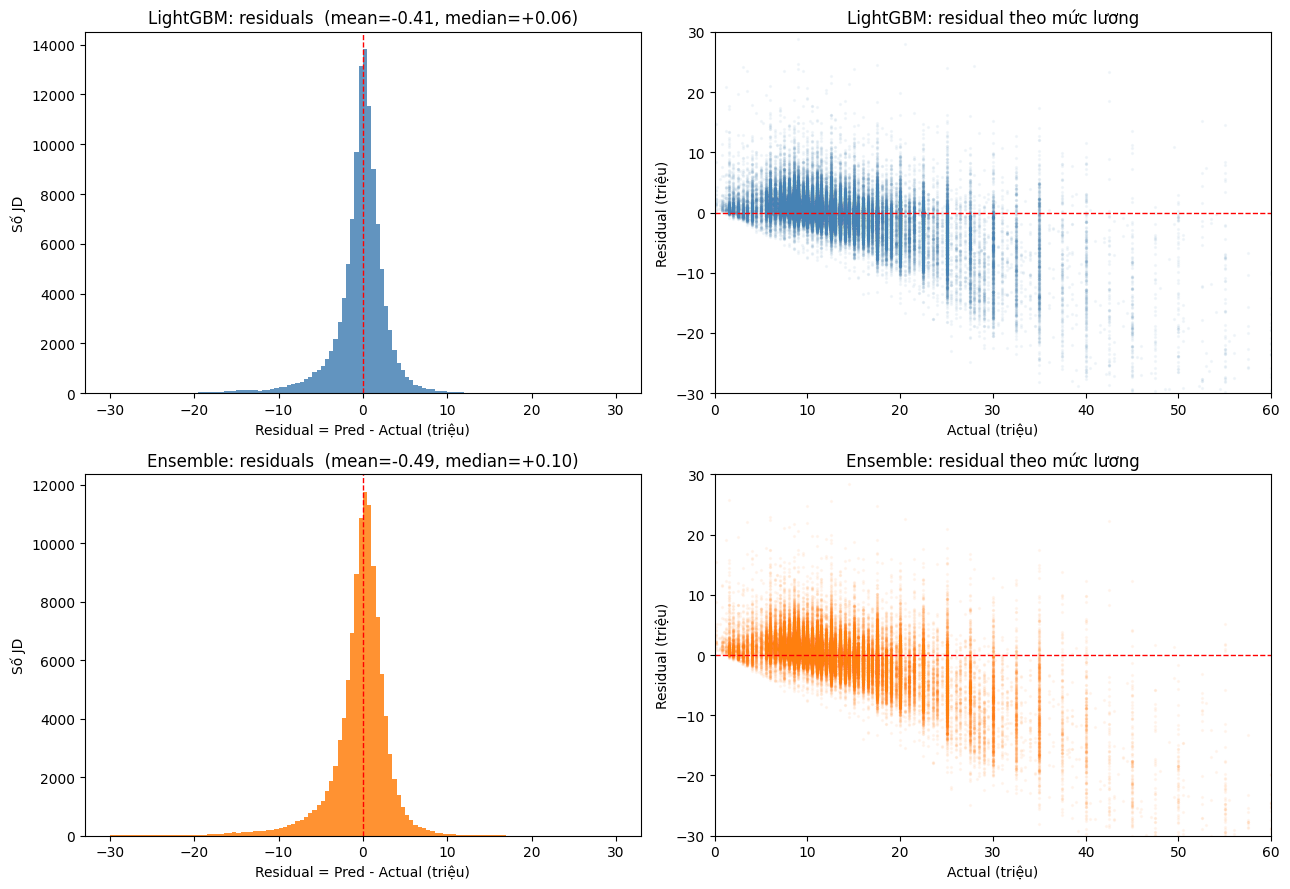

In [31]:
# Residuals của 2 model tốt nhất: LightGBM vs Ensemble
res_lgbm = np.clip(preds_dict['LightGBM'], 0, None) - y_test_M
res_ens = np.clip(preds_dict['Ensemble (weighted)'], 0, None) - y_test_M

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (name, residuals) in enumerate([('LightGBM', res_lgbm), ('Ensemble', res_ens)]):
    ax = axes[row, 0]
    ax.hist(residuals, bins=120, range=(-30, 30), color='steelblue' if row == 0 else 'tab:orange', alpha=0.85)
    ax.axvline(0, color='r', linestyle='--', lw=1)
    ax.set_xlabel('Residual = Pred - Actual (triệu)')
    ax.set_ylabel('Số JD')
    ax.set_title(f'{name}: residuals  (mean={residuals.mean():+.2f}, median={np.median(residuals):+.2f})')

    ax = axes[row, 1]
    ax.scatter(y_test_M, residuals, s=2, alpha=0.05, color='steelblue' if row == 0 else 'tab:orange')
    ax.axhline(0, color='r', linestyle='--', lw=1)
    ax.set_xlim(0, 60)
    ax.set_ylim(-30, 30)
    ax.set_xlabel('Actual (triệu)')
    ax.set_ylabel('Residual (triệu)')
    ax.set_title(f'{name}: residual theo mức lương')
plt.tight_layout()
plt.savefig(FIGURES / 'residuals.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Feature importance — top 30

So sánh hệ số Ridge (có dấu, linear) với gain LightGBM (không dấu, tree).

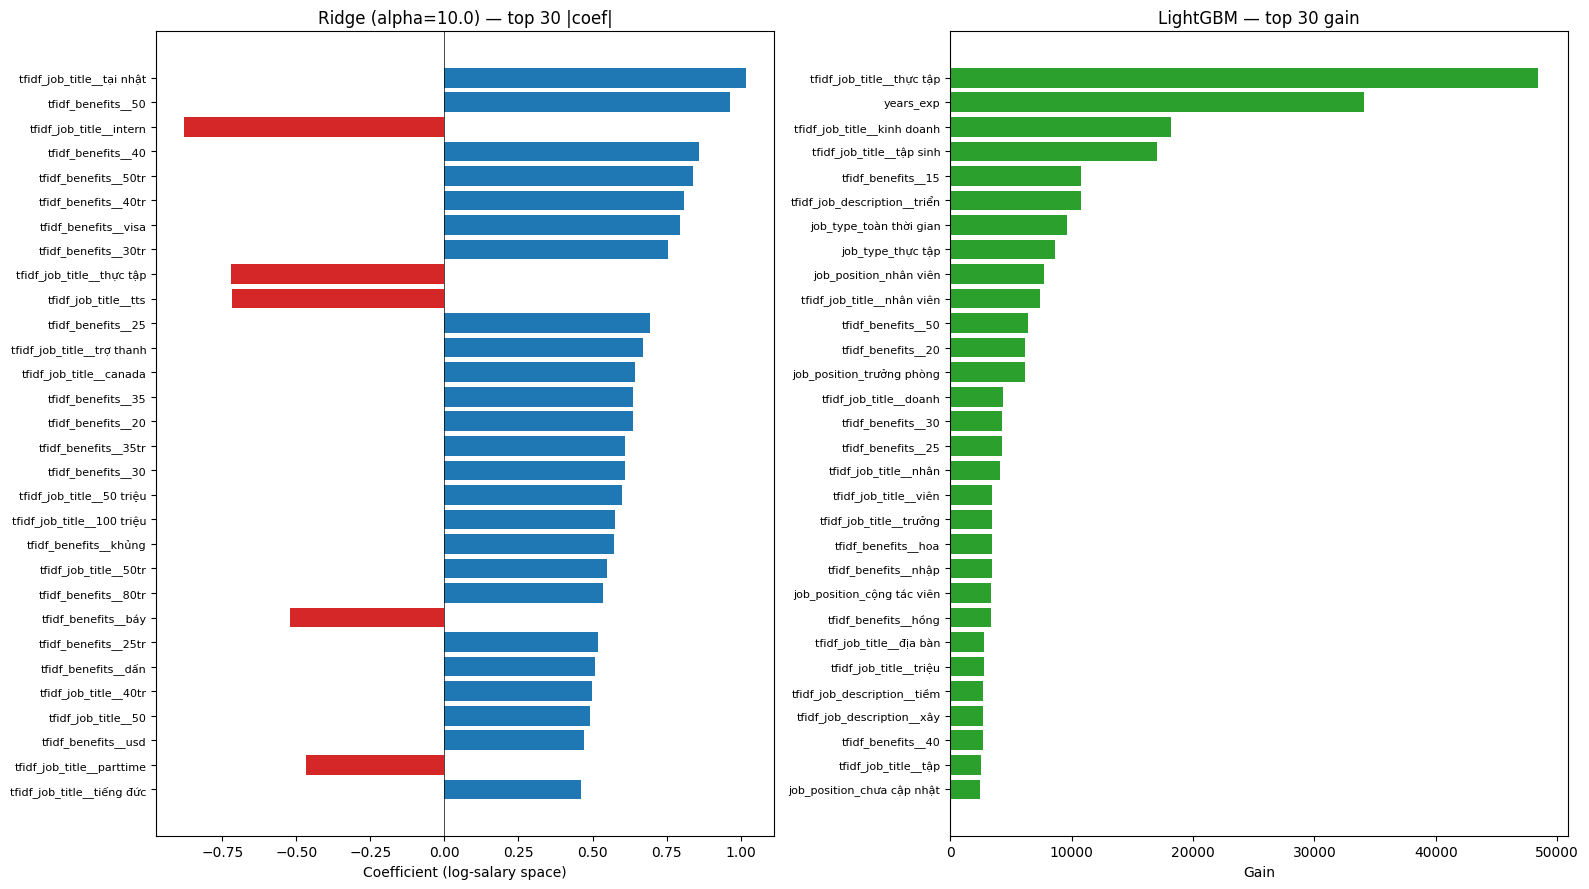

In [32]:
ridge_imp = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge_final.coef_,
})
ridge_imp['abs_coef'] = ridge_imp['coef'].abs()
ridge_top = ridge_imp.nlargest(30, 'abs_coef').iloc[::-1]

lgbm_imp = pd.DataFrame({
    'feature': feature_names,
    'gain': lgbm_final.feature_importance(importance_type='gain'),
})
lgbm_top = lgbm_imp.nlargest(30, 'gain').iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
ax = axes[0]
colors = ['tab:red' if c < 0 else 'tab:blue' for c in ridge_top['coef']]
ax.barh(range(len(ridge_top)), ridge_top['coef'], color=colors)
ax.set_yticks(range(len(ridge_top)))
ax.set_yticklabels(ridge_top['feature'], fontsize=8)
ax.set_title(f'Ridge (alpha={best_alpha_ridge}) — top 30 |coef|')
ax.set_xlabel('Coefficient (log-salary space)')
ax.axvline(0, color='k', lw=0.5)

ax = axes[1]
ax.barh(range(len(lgbm_top)), lgbm_top['gain'], color='tab:green')
ax.set_yticks(range(len(lgbm_top)))
ax.set_yticklabels(lgbm_top['feature'], fontsize=8)
ax.set_title(f'LightGBM — top 30 gain')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Sai số phân tầng — LightGBM & Ensemble

MAE theo `years_exp` và `first_industry` → phát hiện nhóm model dự đoán kém. So sánh LightGBM (model gốc tốt nhất) với Ensemble.

In [33]:
df_err = pd.DataFrame({
    'actual': y_test_M,
    'pred_lgbm': np.clip(preds_dict['LightGBM'], 0, None),
    'pred_ens': np.clip(preds_dict['Ensemble (weighted)'], 0, None),
    'years_exp': clean_test_full['years_exp'].values,
    'industry': clean_test_full['industries_list'].fillna('Other').str.split('|').str[0].values,
})
df_err['err_lgbm'] = (df_err['pred_lgbm'] - df_err['actual']).abs()
df_err['err_ens'] = (df_err['pred_ens'] - df_err['actual']).abs()

print("MAE theo years_exp (LightGBM vs Ensemble):")
g = df_err.groupby('years_exp', dropna=False).agg(
    mae_lgbm=('err_lgbm', 'mean'),
    mae_ens=('err_ens', 'mean'),
    n=('err_lgbm', 'count'),
).round(3)
print(g.to_string())

print("\nTop 5 ngành MAE thấp nhất theo Ensemble (n >= 500):")
g2 = df_err.groupby('industry').agg(
    mae_lgbm=('err_lgbm', 'mean'),
    mae_ens=('err_ens', 'mean'),
    n=('err_lgbm', 'count'),
).query('n >= 500').round(3)
print(g2.nsmallest(5, 'mae_ens').to_string())

print("\nTop 5 ngành MAE cao nhất theo Ensemble (n >= 500):")
print(g2.nlargest(5, 'mae_ens').to_string())

MAE theo years_exp (LightGBM vs Ensemble):
           mae_lgbm  mae_ens      n
years_exp                          
0.5           1.968    2.091   1228
1.0           2.119    2.353  31556
2.0           1.991    2.177  18078
3.0           2.035    2.212  34719
4.0           2.269    2.441  16383
5.0           2.929    3.160   7409
6.0           3.481    3.618    533
7.0           3.930    4.343   1840
8.0           5.214    5.606    663
NaN           2.106    2.313   2364

Top 5 ngành MAE thấp nhất theo Ensemble (n >= 500):
                                    mae_lgbm  mae_ens      n
industry                                                    
Lao động phổ thông                     1.213    1.387   4583
Kế toán                                1.550    1.650  10215
Thu mua - Kho Vận - Chuỗi cung ứng     1.525    1.655   1583
Hành chính - Thư ký                    1.791    1.858   1980
Nhân sự                                1.770    1.866   2771

Top 5 ngành MAE cao nhất theo Ensemble (n >=

### Trực quan — heatmap MAE theo `industry × years_exp` (LightGBM)

Phân tầng sai số 2 chiều: hàng = top 15 ngành (theo số JD test), cột = years_exp. Annotation = MAE (triệu). Cell nào trống/rất ít sample (< 20 JD) → để xám. Self-contained, đọc `models/predictions_test.csv` + `clean_data/clean_data_test.csv`.

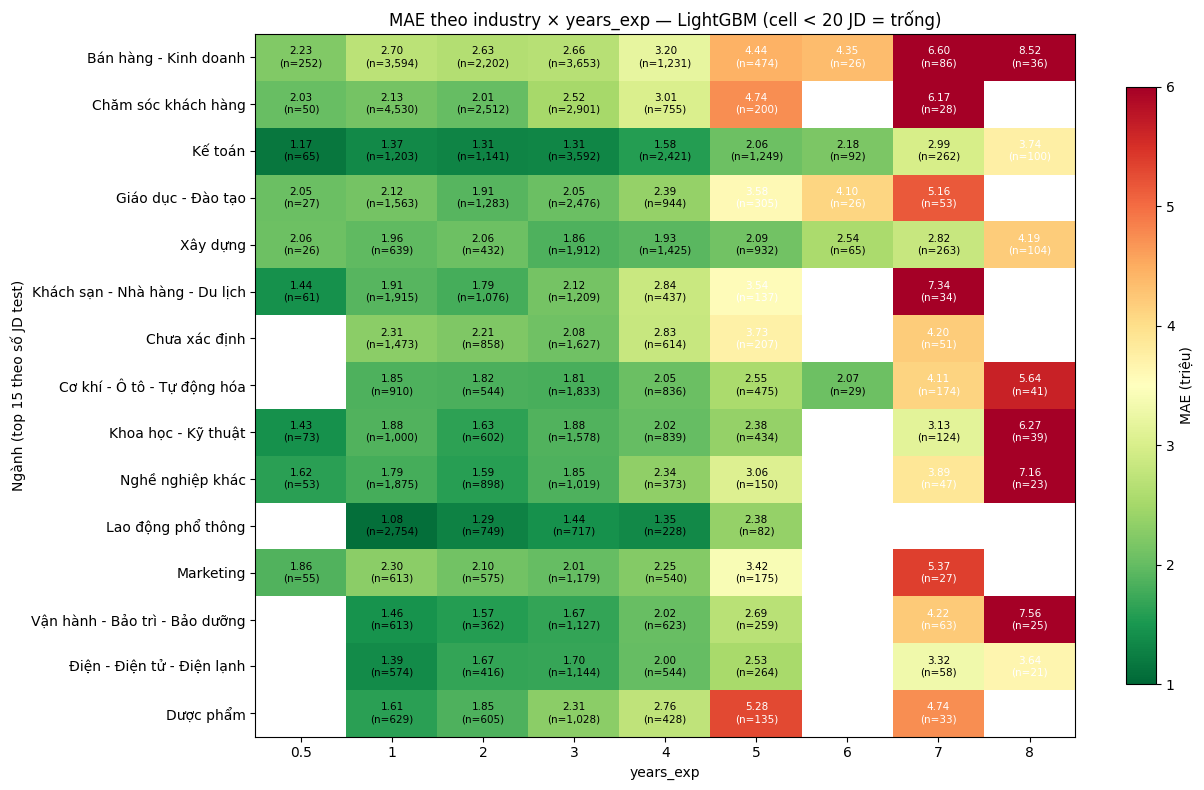

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\segment_mae_heatmap.png


In [39]:
preds = pd.read_csv(MODELS / 'predictions_test.csv')
clean_te = pd.read_csv(CLEAN / 'clean_data_test.csv', usecols=['industries_list', 'years_exp'])

df_seg = pd.DataFrame({
    'actual': preds['actual'].values,
    'pred': preds['lightgbm'].values,
    'industry': clean_te['industries_list'].fillna('Other').str.split('|').str[0].values,
    'years_exp': clean_te['years_exp'].values,
})
df_seg['err'] = (df_seg['pred'] - df_seg['actual']).abs()

# Top 15 ngành theo số JD test
top_ind = df_seg['industry'].value_counts().head(15).index.tolist()
exp_levels = sorted([x for x in df_seg['years_exp'].dropna().unique()])

mae_matrix = np.full((len(top_ind), len(exp_levels)), np.nan)
cnt_matrix = np.zeros_like(mae_matrix, dtype=int)
for i, ind in enumerate(top_ind):
    for j, exp in enumerate(exp_levels):
        sub = df_seg[(df_seg['industry'] == ind) & (df_seg['years_exp'] == exp)]
        if len(sub) >= 20:
            mae_matrix[i, j] = sub['err'].mean()
            cnt_matrix[i, j] = len(sub)

fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(mae_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1.0, vmax=6.0)

ax.set_xticks(np.arange(len(exp_levels)))
ax.set_xticklabels([f"{e:g}" for e in exp_levels])
ax.set_yticks(np.arange(len(top_ind)))
ax.set_yticklabels(top_ind, fontsize=10)
ax.set_xlabel('years_exp')
ax.set_ylabel('Ngành (top 15 theo số JD test)')
ax.set_title('MAE theo industry × years_exp — LightGBM (cell < 20 JD = trống)')

for i in range(len(top_ind)):
    for j in range(len(exp_levels)):
        v = mae_matrix[i, j]
        if np.isnan(v):
            continue
        txt_color = 'white' if v > 3.5 else 'black'
        ax.text(j, i, f"{v:.2f}\n(n={cnt_matrix[i,j]:,})",
                ha='center', va='center', fontsize=7.5, color=txt_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label('MAE (triệu)')

plt.tight_layout()
plt.savefig(FIGURES / 'segment_mae_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIGURES / 'segment_mae_heatmap.png'}")

## 14. Lưu artifact

- `models/lgbm_best.txt`, `models/lgbm_no_year.txt` — LightGBM native (portable, không cần joblib).
- `models/ridge_final.joblib`, `models/sgd_final.joblib` — sklearn pickled.
- `models/predictions_test.csv` — predictions của các model + ensemble trên test.
- `models/metrics.csv`, `models/hyperparams.json`, `models/optuna_trials.json` — đã lưu ở các bước trên/dưới.

In [34]:
# LightGBM C++ writer không support path Unicode (dấu tiếng Việt) trên Windows.
# Dùng model_to_string() rồi ghi qua Python để vượt giới hạn này.
(MODELS / 'lgbm_best.txt').write_text(lgbm_final.model_to_string(), encoding='utf-8')
(MODELS / 'lgbm_no_year.txt').write_text(lgbm_no_year.model_to_string(), encoding='utf-8')
joblib.dump(ridge_final, MODELS / 'ridge_final.joblib', compress=3)
joblib.dump(sgd_final, MODELS / 'sgd_final.joblib', compress=3)

preds_df = pd.DataFrame({
    'actual': y_test_M,
    'baseline': preds_dict['Baseline'],
    'ridge': preds_dict['Ridge'],
    'lasso_sgd': preds_dict['Lasso-SGD'],
    'lightgbm': preds_dict['LightGBM'],
    'lightgbm_no_year': np.expm1(y_pred_ny_log),
    'ensemble_weighted': preds_dict['Ensemble (weighted)'],
    'ensemble_simple_avg': np.expm1(y_pred_avg_log),
}).round(3)
preds_df.to_csv(MODELS / 'predictions_test.csv', index=False, encoding='utf-8-sig')

# Lưu Optuna study (chỉ trial data, không lưu state machine để tránh pickle issues)
optuna_trials_summary = [
    {
        'number': t.number,
        'state': t.state.name,
        'value': t.value,
        'params': t.params,
        'best_iter_median': t.user_attrs.get('best_iter_median'),
        'duration_sec': (t.datetime_complete - t.datetime_start).total_seconds() if t.datetime_complete else None,
    }
    for t in study.trials
]
(MODELS / 'optuna_trials.json').write_text(
    json.dumps(optuna_trials_summary, indent=2, ensure_ascii=False, default=str),
    encoding='utf-8',
)

hparams = {
    'ridge_alpha': float(best_alpha_ridge),
    'sgd_alpha': float(best_alpha_sgd),
    'lgbm_best_params': {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in study.best_params.items()},
    'lgbm_n_estimators': int(n_estimators_full),
    'lgbm_cv_mae': float(study.best_value),
    'ensemble_weights': {
        'ridge': float(weights[0]),
        'lasso_sgd': float(weights[1]),
        'lightgbm': float(weights[2]),
    },
    'n_cv_sample': N_SAMPLE,
    'n_folds_linear': N_FOLDS,
    'n_folds_optuna': OPTUNA_CV_FOLDS,
    'n_trials_optuna': OPTUNA_N_TRIALS,
}
(MODELS / 'hyperparams.json').write_text(json.dumps(hparams, indent=2), encoding='utf-8')

print('Đã lưu artifact:')
for fn in sorted(MODELS.iterdir()):
    print(f"  {fn.name:35s} {fn.stat().st_size/1e6:>7.2f} MB")

Đã lưu artifact:
  hyperparams.json                       0.00 MB
  lgbm_best.txt                          7.77 MB
  lgbm_no_year.txt                       7.77 MB
  metrics.csv                            0.00 MB
  optuna_trials.json                     0.01 MB
  predictions_test.csv                   6.01 MB
  ridge_final.joblib                     0.12 MB
  sgd_final.joblib                       0.02 MB


## 15. Bước tiếp theo

- **Báo cáo PDF** (15-20 trang) — dùng [Mau tieu luan KHDL_2026.docx](../Mau%20tieu%20luan%20KHDL_2026.docx) làm template.
- **Slide PDF** ≤ 15 phút — focus vào đặc tính dữ liệu (từ stage 1) + bảng so sánh model + nhận xét.
- Hình ảnh đã có sẵn trong `figures/`:
  - `predicted_vs_actual.png` — 5 hexbin (Baseline, Ridge, Lasso, LightGBM, Ensemble)
  - `residuals.png` — histogram + scatter của LightGBM và Ensemble
  - `feature_importance.png` — Ridge vs LightGBM top 30

Lưu ý: theo [thông báo nộp bài](../2026_MS%20Teams-TB%20nộp%20tiểu%20luận%20cuối%20kỳ_23.15.docx.md), **không được đưa code vào báo cáo**. Dùng bảng/đồ thị + nhận xét bằng prose.